# Customer Churn — Exploratory Data Analysis

Quick EDA companion notebook to `python/churn_model.py`. This notebook
loads the same telecom dataset, looks at churn distribution, key
segments, and correlations, before the modeling script trains and
explains the Random Forest classifier.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv("../data/telecom_customers.csv")
est = df["tenure_months"] * df["monthly_charges"]
df["total_charges"] = df["total_charges"].fillna(est)

df.shape

(55000, 17)

In [2]:
df.head()

,customer_id,gender,senior_citizen,partner,dependents,tenure_months,contract_type,internet_service,multiple_lines,online_security,tech_support,streaming_tv,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,CUST-100000,Female,1,No,No,20,Month-to-month,DSL,No,No,Yes,No,No,Mailed check,42.87,861.50,1
1,CUST-100001,Female,0,Yes,No,66,Month-to-month,DSL,No,Yes,No internet service,No,No,Bank transfer (automatic),45.38,3003.80,0
2,CUST-100002,Female,0,No,Yes,25,Month-to-month,DSL,No,No,No internet service,No,No,Credit card (automatic),48.49,1206.07,0
3,CUST-100003,Female,1,Yes,No,15,Month-to-month,DSL,No,No,No,Yes,No,Electronic check,51.47,745.91,1
4,CUST-100004,Female,0,Yes,No,16,Two year,DSL,Yes,No,No,Yes,Yes,Electronic check,65.06,1024.59,0


## Overall churn rate

Overall churn rate: 35.55%


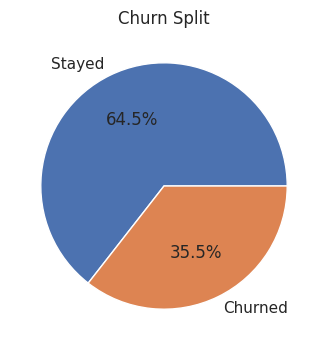

In [3]:
churn_rate = df["churn"].mean() * 100
print(f"Overall churn rate: {churn_rate:.2f}%")

fig, ax = plt.subplots(figsize=(4, 4))
df["churn"].value_counts().rename({0: "Stayed", 1: "Churned"}).plot.pie(
    autopct="%1.1f%%", ax=ax, ylabel=""
)
ax.set_title("Churn Split")
plt.show()

## Churn rate by contract type

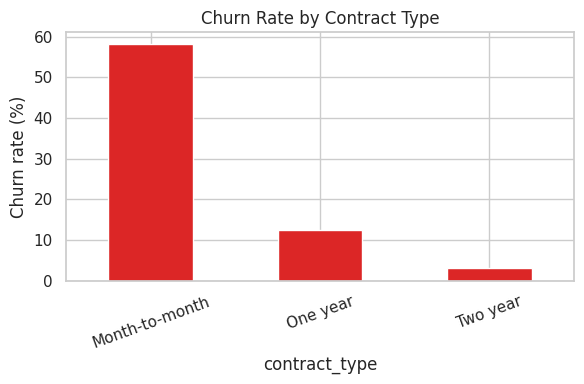

contract_type
Month-to-month    58.184894
One year          12.539779
Two year           3.037323
Name: churn, dtype: float64

In [4]:
seg = df.groupby("contract_type")["churn"].mean().mul(100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(6, 4))
seg.plot.bar(ax=ax, color="#dc2626")
ax.set_ylabel("Churn rate (%)")
ax.set_title("Churn Rate by Contract Type")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

seg

## Tenure vs. monthly charges, colored by churn

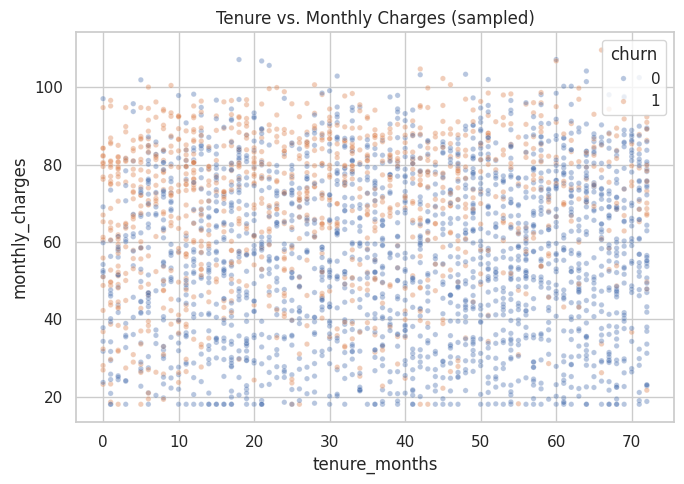

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
sample = df.sample(3000, random_state=42)
sns.scatterplot(
    data=sample, x="tenure_months", y="monthly_charges",
    hue="churn", alpha=0.4, s=15, ax=ax,
)
ax.set_title("Tenure vs. Monthly Charges (sampled)")
plt.tight_layout()
plt.show()

## Correlation of numeric features with churn

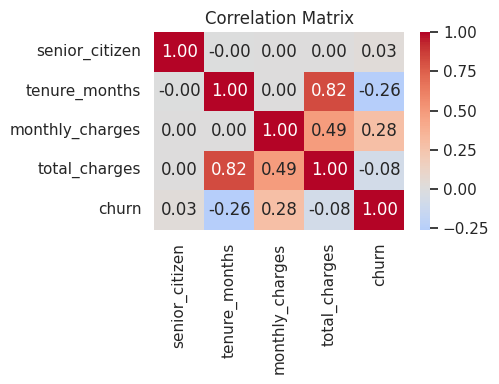

In [6]:
numeric_cols = ["senior_citizen", "tenure_months", "monthly_charges", "total_charges", "churn"]
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Matrix")
plt.tight_layout()
plt.show()

## Takeaways

- Month-to-month contracts churn far more than one/two-year contracts —
  confirmed later by the model's top SHAP driver.
- Low-tenure customers churn at a much higher rate, especially in the
  first 6 months.
- Monthly charges alone isn't strongly correlated with churn — it's the
  *combination* with contract type and tenure that matters, which is why
  the Random Forest + SHAP approach in `python/churn_model.py` outperforms
  a simple single-variable rule.

Next: see `python/churn_model.py` for the classifier, `python/customer_segmentation.py`
for clustering, and `python/ltv_regression.py` for the regression model.
